# GlowWise Skincare - Análise Exploratória dos Dados

Este notebook analisa os dados brutos coletados pelo bot GlowWise Skincare antes da preparação do dataset para Machine Learning.

O objetivo inicial é compreender a estrutura dos dados, identificar possíveis problemas de coleta e documentar as decisões de sanitização.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def encontrar_raiz_projeto():
    arquivo_processado = Path("data") / "processed" / "produtos_sanitizados.csv"
    arquivo_bruto = Path("data") / "raw" / "produtos_coletados_historico.csv"
    candidatos = [Path.cwd(), *Path.cwd().parents, Path.home() / "Documents" / "GlowWise Skincare"]

    for candidato in candidatos:
        if (candidato / arquivo_processado).exists() or (candidato / arquivo_bruto).exists():
            return candidato

    raise FileNotFoundError(
        "Nao encontrei os datasets do projeto. Rode: python ml/gerar_dataset.py"
    )


PROJECT_DIR = encontrar_raiz_projeto()
RAW_PATH = PROJECT_DIR / "data" / "raw" / "produtos_coletados_historico.csv"
PROCESSED_PATH = PROJECT_DIR / "data" / "processed" / "produtos_sanitizados.csv"

print(f"Raiz do projeto: {PROJECT_DIR}")
print(f"Dataset bruto: {RAW_PATH}")
print(f"Dataset processado: {PROCESSED_PATH}")


Raiz do projeto: C:\Users\rebec\Documents\GlowWise Skincare
Dataset bruto: C:\Users\rebec\Documents\GlowWise Skincare\data\raw\produtos_coletados_historico.csv
Dataset processado: C:\Users\rebec\Documents\GlowWise Skincare\data\processed\produtos_sanitizados.csv


In [2]:
df_raw = pd.read_csv(RAW_PATH)
df = pd.read_csv(PROCESSED_PATH)

print("Datasets carregados com sucesso!")
print(f"Bruto: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
print(f"Processado: {df.shape[0]} linhas x {df.shape[1]} colunas")


Datasets carregados com sucesso!
Bruto: 40 linhas x 9 colunas
Processado: 38 linhas x 13 colunas


## Leitura dos dados

A verificação de tipos, dimensões, valores ausentes e duplicidades serve para medir se o dataset está minimamente confiável. Como o volume ainda é pequeno, a prioridade aqui naã é provar significância estatística, e sim confirmar que as colunas principais estão completas para alimentar o pipeline de ML.

As colunas mais importantes para a próxima fase são produto, categoria_busca, loja, preco e termo_busca. Elas viram sinais do modelo de recomendação **vale_comprar** / **nao_vale_comprar**.



In [3]:
df.head()

,run_id,produto_original,produto,marca,termo_busca,categoria_busca,loja,preco,disponivel,data_coleta,link_original,link,link_canonico
0,4649c28fc8bb,"Ada Tina , Niacinamide Gel Concentrado - Gel d...",Niacinamide Gel Concentrado - Gel de Limpeza F...,Ada Tina,gel de limpeza facial niacinamida,limpeza,Beleza na Web,170.79,True,2026-06-05 02:41:19,https://www.belezanaweb.com.br/ada-tina-niacin...,https://www.belezanaweb.com.br/ada-tina-niacin...,https://www.belezanaweb.com.br/ada-tina-niacin...
1,4649c28fc8bb,"Avène , Cleanance Aqua-Gel - Hidratante Facial...",Cleanance Aqua-Gel - Hidratante Facial 30g,Avène,hidratante facial niacinamida,hidratacao,Beleza na Web,148.90,True,2026-06-05 02:40:56,https://www.belezanaweb.com.br/avene-cleanance...,https://www.belezanaweb.com.br/avene-cleanance...,https://www.belezanaweb.com.br/avene-cleanance...
2,4649c28fc8bb,"o Boticário , Botik Vitamina C - Gel de Limpez...",Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,gel de limpeza facial vitamina c,limpeza,Beleza na Web,87.90,True,2026-06-05 02:41:07,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...
3,4649c28fc8bb,"o Boticário , Botik Vitamina C - Gel de Limpez...",Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,gel de limpeza facial vitamina c,limpeza,Beleza na Web,29.90,True,2026-06-05 02:41:07,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...
4,4649c28fc8bb,"Carla Leone , Niacinamida 10% + Zinco 1% - Sér...",Niacinamida 10% + Zinco 1% - Sérum Hidratante ...,Carla Leone,hidratante facial niacinamida,hidratacao,Beleza na Web,79.90,True,2026-06-05 02:40:56,https://www.belezanaweb.com.br/carla-leone-nia...,https://www.belezanaweb.com.br/carla-leone-nia...,https://www.belezanaweb.com.br/carla-leone-nia...


In [4]:
df.shape

(38, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   run_id            38 non-null     object 
 1   produto_original  38 non-null     object 
 2   produto           38 non-null     object 
 3   marca             38 non-null     object 
 4   termo_busca       38 non-null     object 
 5   categoria_busca   38 non-null     object 
 6   loja              38 non-null     object 
 7   preco             38 non-null     float64
 8   disponivel        38 non-null     bool   
 9   data_coleta       38 non-null     object 
 10  link_original     38 non-null     object 
 11  link              38 non-null     object 
 12  link_canonico     38 non-null     object 
dtypes: bool(1), float64(1), object(11)
memory usage: 3.7+ KB


In [6]:
df.dtypes

run_id               object
produto_original     object
produto              object
marca                object
termo_busca          object
categoria_busca      object
loja                 object
preco               float64
disponivel             bool
data_coleta          object
link_original        object
link                 object
link_canonico        object
dtype: object

In [7]:
df.isna().sum()

run_id              0
produto_original    0
produto             0
marca               0
termo_busca         0
categoria_busca     0
loja                0
preco               0
disponivel          0
data_coleta         0
link_original       0
link                0
link_canonico       0
dtype: int64

## Valores ausentes

O dataset bruto possui 81 registros e não apresentou valores nulos ou textos vazios nas colunas analisadas.

A coluna *preco* já foi coletada como valor numérico decimal. A coluna *disponivel* foi reconhecida como booleana. A coluna *data_coleta*, embora preenchida, ainda está armazenada como texto e deverá ser convertida durante a sanitização.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["produto"].value_counts().head(10)

produto
Niacinamide Gel Concentrado - Gel de Limpeza Facial 250ml     1
Cleanance Aqua-Gel - Hidratante Facial 30g                    1
Botik Vitamina C - Gel de Limpeza Facial Antioxidante 200g    1
Botik Vitamina C - Gel de Limpeza Facial Antioxidante 50g     1
Niacinamida 10% + Zinco 1% - Sérum Hidratante Facial 30ml     1
Niacinamida + Zinco - Gel de Limpeza Facial 60ml              1
Acne Control - Gel de Limpeza Facial 340g                     1
Acne Control Refil - Gel de Limpeza Facial 227g               1
Peles Equilibradas a Oleosas - Gel de Limpeza Facial 150g     1
Vitamina C - Sérum Facial 30g                                 1
Name: count, dtype: int64

In [10]:
df["run_id"].nunique()

1

In [11]:
df["loja"].value_counts()

loja
Beleza na Web    38
Name: count, dtype: int64

In [12]:
df["categoria_busca"].value_counts()

categoria_busca
limpeza       19
hidratacao    19
Name: count, dtype: int64

In [13]:
df["termo_busca"].value_counts()

termo_busca
hidratante facial vitamina c         10
gel de limpeza facial vitamina c     10
hidratante facial niacinamida         9
gel de limpeza facial niacinamida     9
Name: count, dtype: int64

## Distribuição dos produtos

A coleta possui produtos de duas lojas diferentes. As categorias não ficaram igualmente distribuídas, pois algumas buscas retornaram mais itens do que outras.

A categoria de tratamento apresentou menor quantidade de registros e poderá precisar de novas buscas para melhorar o dataset.

In [14]:
df["preco"].describe()

count     38.000000
mean     142.641316
std      125.859059
min       29.900000
25%       61.475000
50%      102.395000
75%      168.445000
max      592.790000
Name: preco, dtype: float64

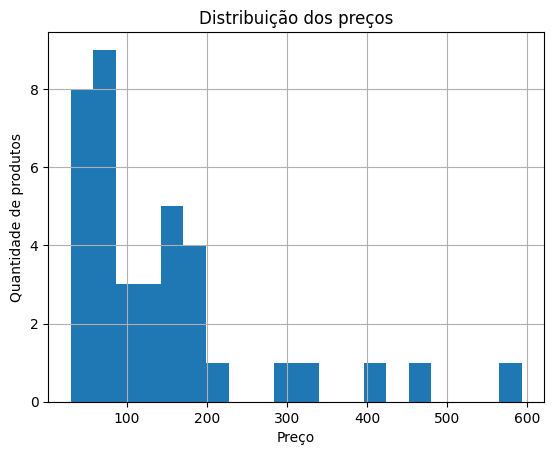

In [15]:
df["preco"].hist(bins=20)

plt.title("Distribuição dos preços")
plt.xlabel("Preço")
plt.ylabel("Quantidade de produtos")
plt.show()

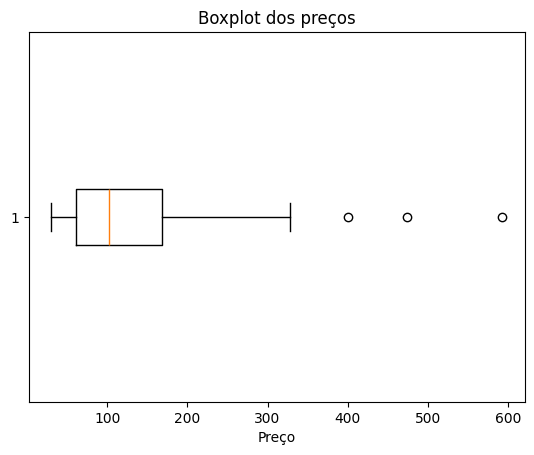

In [16]:
plt.boxplot(df["preco"], vert=False)

plt.title("Boxplot dos preços")
plt.xlabel("Preço")
plt.show()

## Análise dos preços

A maior parte dos produtos está concentrada em uma faixa de preço mais baixa, mas existem valores mais altos que se destacam da distribuição.

Esses valores serão analisados antes da preparação do dataset para verificar se representam produtos premium ou possíveis inconsistências de coleta.

In [17]:
df_raw["link"].str.contains("criteo.com", case=False, na=False).sum()


np.int64(0)

## Qualidade dos links

A presença de redirecionadores nos links brutos mostra um problema típico de scraping em páginas de e-commerce. Se esses links forem usados sem limpeza, produtos iguais podem parecer diferentes e prejudicar a deduplicação.

Por isso o dataset processado preserva o link original, mas também cria uma versão canônica/limpa para análise, histórico e comparação entre execuções.


In [18]:
df_raw[df_raw["link"].str.contains("criteo.com", case=False, na=False)][
    ["produto", "loja", "link"]
].head()


,produto,loja,link


In [19]:
print("Comparativo bruto x processado")
print(f"Linhas no bruto: {len(df_raw)}")
print(f"Linhas no processado: {len(df)}")
print(f"Duplicatas removidas no processamento: {len(df_raw) - len(df)}")


Comparativo bruto x processado
Linhas no bruto: 40
Linhas no processado: 38
Duplicatas removidas no processamento: 2


In [20]:
df[["produto_original", "produto", "marca", "loja", "preco"]].head(10)


,produto_original,produto,marca,loja,preco
0,"Ada Tina , Niacinamide Gel Concentrado - Gel d...",Niacinamide Gel Concentrado - Gel de Limpeza F...,Ada Tina,Beleza na Web,170.79
1,"Avène , Cleanance Aqua-Gel - Hidratante Facial...",Cleanance Aqua-Gel - Hidratante Facial 30g,Avène,Beleza na Web,148.90
2,"o Boticário , Botik Vitamina C - Gel de Limpez...",Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,Beleza na Web,87.90
3,"o Boticário , Botik Vitamina C - Gel de Limpez...",Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,Beleza na Web,29.90
4,"Carla Leone , Niacinamida 10% + Zinco 1% - Sér...",Niacinamida 10% + Zinco 1% - Sérum Hidratante ...,Carla Leone,Beleza na Web,79.90
5,"Carla Leone , Niacinamida + Zinco - Gel de Lim...",Niacinamida + Zinco - Gel de Limpeza Facial 60ml,Carla Leone,Beleza na Web,49.90
6,"CeraVe , Acne Control - Gel de Limpeza Facial ...",Acne Control - Gel de Limpeza Facial 340g,Cerave,Beleza na Web,105.90
7,"CeraVe , Acne Control Refil - Gel de Limpeza F...",Acne Control Refil - Gel de Limpeza Facial 227g,Cerave,Beleza na Web,65.90
8,"CeraVe , Peles Equilibradas a Oleosas - Gel de...",Peles Equilibradas a Oleosas - Gel de Limpeza ...,Cerave,Beleza na Web,69.90
9,"Creamy , Vitamina C - Sérum Facial 30g , VIRAL...",Vitamina C - Sérum Facial 30g,Creamy,Beleza na Web,150.00


In [21]:
checks_qualidade = {
    "valores_ausentes": int(df.isna().sum().sum()),
    "links_criteo_restantes": int(df["link"].str.contains("criteo.com", case=False, na=False).sum()),
    "links_canonicos_duplicados": int(df["link_canonico"].duplicated().sum()),
    "produtos_com_virgula_final": int(df["produto"].str.contains(r",\s*$", na=False).sum()),
}

pd.Series(checks_qualidade).to_frame("quantidade")


,quantidade
valores_ausentes,0
links_criteo_restantes,0
links_canonicos_duplicados,0
produtos_com_virgula_final,0


## Controles de qualidade

Os checks de qualidade funcionam como uma pequena auditoria do dataset. Eles ajudam a responder perguntas práticas: ainda existem links redirecionados? há registros sem preço? os nomes de produtos ficaram aproveitáveis?

Esses controles também são úteis para o monitoramento futuro com Evidently AI, porque definem o que esperamos de uma coleta saudável.


In [22]:
df["marca"].value_counts().head(15)


marca
Garnier               4
Cerave                3
Payot                 3
E Se? Cosméticos      3
Creamy                3
Carla Leone           2
Océane                2
Kokeshi Cosméticos    2
O Boticário           2
La Roche-Posay        2
Ada Tina              1
Avène                 1
Eudora                1
État Pur              1
Darrow                1
Name: count, dtype: int64

In [23]:
df[["produto", "marca", "termo_busca", "categoria_busca", "loja", "preco"]].head()


,produto,marca,termo_busca,categoria_busca,loja,preco
0,Niacinamide Gel Concentrado - Gel de Limpeza F...,Ada Tina,gel de limpeza facial niacinamida,limpeza,Beleza na Web,170.79
1,Cleanance Aqua-Gel - Hidratante Facial 30g,Avène,hidratante facial niacinamida,hidratacao,Beleza na Web,148.90
2,Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,gel de limpeza facial vitamina c,limpeza,Beleza na Web,87.90
3,Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,gel de limpeza facial vitamina c,limpeza,Beleza na Web,29.90
4,Niacinamida 10% + Zinco 1% - Sérum Hidratante ...,Carla Leone,hidratante facial niacinamida,hidratacao,Beleza na Web,79.90


## Ponte para a modelagem

Esta visão final mostra exatamente as colunas que entram no notebook de modelagem. O texto do produto e a marca alimentam a parte textual do pipeline, categoria e loja entram como variáveis categóricas e preço entra como variável numérica.

Assim, a EDA fecha o ciclo com uma decisao clara: o modelo de ML sera um recomendador baseado em classificacao binaria, usando os sinais que a exploracao mostrou serem mais consistentes.


In [24]:
print("O dataset processado e usado nesta EDA e gerado por ml/gerar_dataset.py.")
print(f"Arquivo analisado: {PROCESSED_PATH}")


O dataset processado e usado nesta EDA e gerado por ml/gerar_dataset.py.
Arquivo analisado: C:\Users\rebec\Documents\GlowWise Skincare\data\processed\produtos_sanitizados.csv


## Análise dos links

Alguns links coletados utilizavam redirecionadores. Para facilitar o uso do dataset, foi criada a coluna *link_limpo*, mantendo também o link original coletado pelo bot.

In [25]:
df.dtypes


run_id               object
produto_original     object
produto              object
marca                object
termo_busca          object
categoria_busca      object
loja                 object
preco               float64
disponivel             bool
data_coleta          object
link_original        object
link                 object
link_canonico        object
dtype: object

In [26]:
df.isna().sum()


run_id              0
produto_original    0
produto             0
marca               0
termo_busca         0
categoria_busca     0
loja                0
preco               0
disponivel          0
data_coleta         0
link_original       0
link                0
link_canonico       0
dtype: int64

In [27]:
df["marca"].value_counts().head(15)


marca
Garnier               4
Cerave                3
Payot                 3
E Se? Cosméticos      3
Creamy                3
Carla Leone           2
Océane                2
Kokeshi Cosméticos    2
O Boticário           2
La Roche-Posay        2
Ada Tina              1
Avène                 1
Eudora                1
État Pur              1
Darrow                1
Name: count, dtype: int64

In [28]:
df.head()


,run_id,produto_original,produto,marca,termo_busca,categoria_busca,loja,preco,disponivel,data_coleta,link_original,link,link_canonico
0,4649c28fc8bb,"Ada Tina , Niacinamide Gel Concentrado - Gel d...",Niacinamide Gel Concentrado - Gel de Limpeza F...,Ada Tina,gel de limpeza facial niacinamida,limpeza,Beleza na Web,170.79,True,2026-06-05 02:41:19,https://www.belezanaweb.com.br/ada-tina-niacin...,https://www.belezanaweb.com.br/ada-tina-niacin...,https://www.belezanaweb.com.br/ada-tina-niacin...
1,4649c28fc8bb,"Avène , Cleanance Aqua-Gel - Hidratante Facial...",Cleanance Aqua-Gel - Hidratante Facial 30g,Avène,hidratante facial niacinamida,hidratacao,Beleza na Web,148.90,True,2026-06-05 02:40:56,https://www.belezanaweb.com.br/avene-cleanance...,https://www.belezanaweb.com.br/avene-cleanance...,https://www.belezanaweb.com.br/avene-cleanance...
2,4649c28fc8bb,"o Boticário , Botik Vitamina C - Gel de Limpez...",Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,gel de limpeza facial vitamina c,limpeza,Beleza na Web,87.90,True,2026-06-05 02:41:07,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...
3,4649c28fc8bb,"o Boticário , Botik Vitamina C - Gel de Limpez...",Botik Vitamina C - Gel de Limpeza Facial Antio...,O Boticário,gel de limpeza facial vitamina c,limpeza,Beleza na Web,29.90,True,2026-06-05 02:41:07,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...,https://www.belezanaweb.com.br/botik-vitamina-...
4,4649c28fc8bb,"Carla Leone , Niacinamida 10% + Zinco 1% - Sér...",Niacinamida 10% + Zinco 1% - Sérum Hidratante ...,Carla Leone,hidratante facial niacinamida,hidratacao,Beleza na Web,79.90,True,2026-06-05 02:40:56,https://www.belezanaweb.com.br/carla-leone-nia...,https://www.belezanaweb.com.br/carla-leone-nia...,https://www.belezanaweb.com.br/carla-leone-nia...


## Limpeza básica

A coluna de data foi convertida para o tipo correto. Também foram removidos espaços extras dos textos e padronizadas algumas colunas para facilitar as próximas análises.

In [29]:
print(f"Dataset processado ja esta salvo em: {PROCESSED_PATH}")
print("Para atualizar este arquivo, rode: python ml/gerar_dataset.py")


Dataset processado ja esta salvo em: C:\Users\rebec\Documents\GlowWise Skincare\data\processed\produtos_sanitizados.csv
Para atualizar este arquivo, rode: python ml/gerar_dataset.py


## Conclusão da EDA

Ao final da EDA, o dataset processado está pronto para treino do modelo e monitoramento de drift. O arquivo bruto continua preservado para rastreabilidade, enquanto o arquivo sanitizado vira a base operacional do ML.

A principal limitação atual é o tamanho da amostra. Por isso, os resultados iniciais devem ser apresentados como uma primeira versão funcional do pipeline, com melhoria natural conforme o bot acumular novas execuções.


In [30]:
len(df)

38

## Dataset processado

Após a análise exploratória e a limpeza básica, o dataset sanitizado foi salvo em *data/processed/produtos_sanitizados.csv*.

O arquivo bruto foi preservado sem alterações.